# Run a retrieval of line-of-sight densities from an ACS solar occultation observation

In this notebook, we are going to show how to use the *acs* Python package to run retrievals for the ACS solar occultation observations using the archNEMESIS radiative transfer algorithm. This notebook presents an alternative method for retrieving line-of-sight densities of atmospheric gases from each tangent height independently rather than performing a full retrieval.

In particular, we are going to assume that we already have created a Measurement class with the information regarding the measurement we want to retrieve. In this measurement, we are observing an absorption band of $^{13}$CO$_2$ encompassed within the spectral range of ACS NIR. Specifically, this spectral range coincides with the diffraction order #52 of ACS NIR.

Here, we are going to run a retrieval to infer the vertical profile of the $^{13}$CO$_2$ line-of-sight density at each tangent height.

In [1]:
import acs
import archnemesis as ans
import matplotlib.pyplot as plt
import numpy as np

## 1. Reading the Measurement

First of all, we read the information regarding the Measurement. This will allready give is information about the spectral range and the geometry of the observations.

In [2]:
filename_true = "synthetic_ini_file"

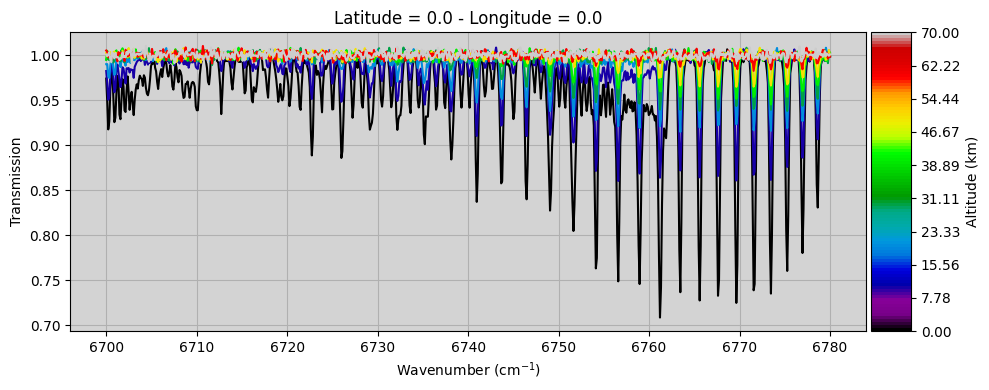

In [3]:
Measurement = ans.Measurement_0()
Measurement.read_hdf5(filename_true)
Measurement.plot_SO()

## 2. Creating reference classes

Now, we are going to initialise all the classes as if we were going to run a forward model. In principle, we do not know the characteristics of the atmosphere that gave rise to the observed spectrum. Therefore, we are going to assume some atmospheric properties, and then will refine these by performing the retrieval and reconstructing the observed transmission spectra.

### 2.1. Atmosphere

Even if in a real retrieval we would not know the characteristics from the Atmosphere, here we do since we generated the measured spectra ourselves. However, to start from a different position, we are going to multiply the atmospheric pressure by a factor of 1.5 so that we do not start from the same answer we are supposed to guess from the retrieval.

In [4]:
Atmosphere = ans.Atmosphere_0()
Atmosphere.read_hdf5(filename_true)
Atmosphere.P *= 1.5  #Multiplying the pressure by 1.5

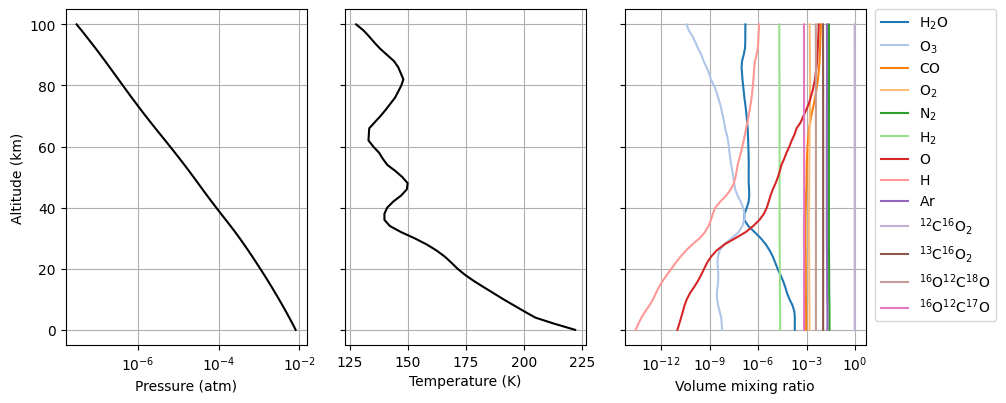

In [5]:
Atmosphere.plot_Atm()

### 2.2. Spectroscopy

In [6]:
#Defining the path to the line-by-line look-up tables
lbl_tables = ["/srv/workspace/data/nemesis/spectroscopy/lbltables/acsnir/archnem/co2_iso1_acsnir_order52.h5",
              "/srv/workspace/data/nemesis/spectroscopy/lbltables/acsnir/archnem/co2_iso2_acsnir_order52.h5"]

In [7]:
Spectroscopy = acs.archnemesis.spectroscopy.create_spectroscopy_lookup_class(lbl_tables)

## 3. Running retrieval

In [8]:
ID_ret = [2] ; ISO_ret = [2]

In [9]:
acs.archnemesis.retrieval_los.run_retrieval("retrieval_example_los",Atmosphere,Measurement,Spectroscopy,ID_ret,ISO_ret)

INFO :: read_tables :: Spectroscopy_0.py-1461 :: Reading tables
Tangent height  1 of 8
Tangent height  2 of 8
Tangent height  3 of 8
Tangent height  4 of 8
Tangent height  5 of 8
Tangent height  6 of 8
Tangent height  7 of 8
Tangent height  8 of 8


## 4. Exploring the results

In [12]:
los_retrieval_data = acs.archnemesis.retrieval_los.read_output("retrieval_example_los")

print("Fields in the data :",los_retrieval_data.keys())

Fields in the data : dict_keys(['NGEOM', 'NCONV', 'TANHE', 'VCONV', 'MEAS', 'ERRMEAS', 'SPECMOD_trace', 'SPECMOD_sigma', 'SPECMOD_background', 'BASELINE', 'ID', 'ISO', 'VMR_ret', 'VMR_reterr', 'LOSDENS'])


### 4.1. Plotting the best fits

Text(0.5, 0, 'Wavenumber (cm$^{-1}$)')

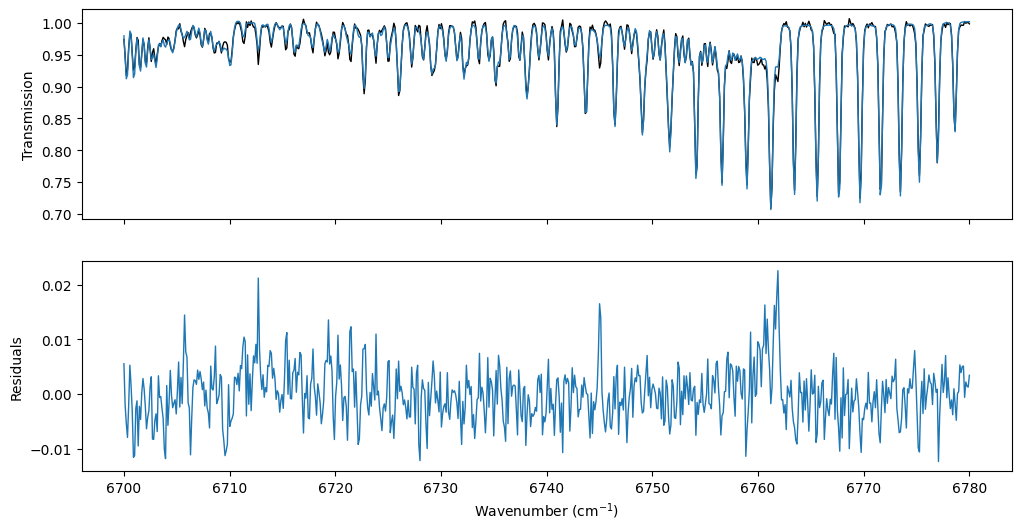

In [13]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(12,6),sharex=True)
igeom = 0
ax1.plot(los_retrieval_data["VCONV"],los_retrieval_data["MEAS"][:,igeom],c="black",linewidth=1.,label="Measured")
ax1.plot(los_retrieval_data["VCONV"],los_retrieval_data["SPECMOD_trace"][:,igeom],linewidth=1.,label="Best fit")

ax2.plot(los_retrieval_data["VCONV"],los_retrieval_data["SPECMOD_trace"][:,igeom]-los_retrieval_data["MEAS"][:,igeom],linewidth=1.,label="Best fit")

ax1.set_ylabel("Transmission")
ax2.set_ylabel("Residuals")
ax2.set_xlabel("Wavenumber (cm$^{-1}$)")

### 4.2. Plotting the retrieved line-of-sight column densities

(8, 1)


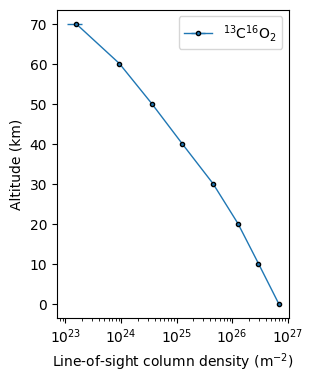

In [27]:
fig,ax1 = plt.subplots(1,1,figsize=(3,4))

print(los_retrieval_data["VMR_ret"].shape)

NGAS = len(los_retrieval_data["ID"])
for igas in range(NGAS):

    gasname = ans.Data.gas_data.id_to_name(los_retrieval_data["ID"][igas],los_retrieval_data["ISO"][igas])
    gaslabel = ans.Data.gas_data.molecule_to_latex(gasname)
    
    ax1.errorbar(
        los_retrieval_data["LOSDENS"] * los_retrieval_data["VMR_ret"][:, igas],
        los_retrieval_data["TANHE"],
        xerr=los_retrieval_data["LOSDENS"] * los_retrieval_data["VMR_reterr"][:, igas],
        fmt="o-",
        markersize=3,
        markeredgecolor="black",
        linewidth=1,
        label="$"+gaslabel+"$",
    )
ax1.legend()
ax1.set_xlabel("Line-of-sight column density (m$^{-2}$)")
ax1.set_ylabel("Altitude (km)")
ax1.set_xscale("log")